In [2]:
import polars as pl
from plotnine import *
import re

theme_set(theme_bw())

In [3]:
# command for generating the s3_status.json file (it isn't actually JSON though, don't know why)
# aws s3 ls --output json s3://sandpiper-woodcrob/test/ >s3_status.json
# aws s3 ls --output json s3://woodcrob-sandpiper-us-east-1/unannotated/ >s3_status.json


# Preprocess the file
with open('s3_status.json', 'r') as file:
    content = file.read()

# Replace multiple delimiters with a single delimiter (e.g., ',')
content = re.sub(r' +', ' ', content)

# Write the preprocessed content to a temporary file
with open('/tmp/temp.csv', 'w') as temp_file:
    temp_file.write(content)

# Read the preprocessed file into Polars
df = pl.read_csv('/tmp/temp.csv')

s3 = pl.read_csv('/tmp/temp.csv', has_header=False, separator=' ')
s3[:3], s3[-3:]

(shape: (3, 4)
 ┌────────────┬──────────┬──────────┬─────────────────────────────────┐
 │ column_1   ┆ column_2 ┆ column_3 ┆ column_4                        │
 │ ---        ┆ ---      ┆ ---      ┆ ---                             │
 │ str        ┆ str      ┆ i64      ┆ str                             │
 ╞════════════╪══════════╪══════════╪═════════════════════════════════╡
 │ 2025-02-28 ┆ 14:07:08 ┆ 167496   ┆ DRR003618.unannotated.singlem.… │
 │ 2025-02-27 ┆ 21:13:31 ┆ 306707   ┆ DRR003623.unannotated.singlem.… │
 │ 2025-02-27 ┆ 18:58:02 ┆ 395471   ┆ DRR003635.unannotated.singlem.… │
 └────────────┴──────────┴──────────┴─────────────────────────────────┘,
 shape: (3, 4)
 ┌────────────┬──────────┬──────────┬─────────────────────────────────┐
 │ column_1   ┆ column_2 ┆ column_3 ┆ column_4                        │
 │ ---        ┆ ---      ┆ ---      ┆ ---                             │
 │ str        ┆ str      ┆ i64      ┆ str                             │
 ╞════════════╪══════════╪═══════

In [4]:
s3.columns = ['date', 'time', 'size','file']
s3[:3]

date,time,size,file
str,str,i64,str
"""2025-02-28""","""14:07:08""",167496,"""DRR003618.unannotated.singlem.…"
"""2025-02-27""","""21:13:31""",306707,"""DRR003623.unannotated.singlem.…"
"""2025-02-27""","""18:58:02""",395471,"""DRR003635.unannotated.singlem.…"


In [5]:
s3 = s3.with_columns(pl.col('file').str.split('.').list.get(0).alias('acc'))
# date and time are in separate columns, so we need to combine them into a single column datetime
s3 = s3.with_columns((pl.col('date') + ' ' + pl.col('time')).str.to_datetime("%Y-%m-%d %H:%M:%S").alias('datetime'))
s3[:3]

date,time,size,file,acc,datetime
str,str,i64,str,str,datetime[μs]
"""2025-02-28""","""14:07:08""",167496,"""DRR003618.unannotated.singlem.…","""DRR003618""",2025-02-28 14:07:08
"""2025-02-27""","""21:13:31""",306707,"""DRR003623.unannotated.singlem.…","""DRR003623""",2025-02-27 21:13:31
"""2025-02-27""","""18:58:02""",395471,"""DRR003635.unannotated.singlem.…","""DRR003635""",2025-02-27 18:58:02


In [6]:
# Original data
acc20k = pl.read_csv('runlists/acc_less_than_20k_mbytes.csv', has_header=False)
acc20k.columns = ['acc']
acc20k[:3]

df = pl.read_csv('~/git/sandpiper/sra_metadata/sra_metadata_20250220.some_columns.csv.gz', has_header=False)
df.columns = ['acc','releasedate','mbases','mbytes']
df[:4]

merged20k = acc20k.join(df, on='acc', how='inner')
merged20k[:3], merged20k.shape

(shape: (3, 4)
 ┌─────────────┬───────────────────────────┬────────┬────────┐
 │ acc         ┆ releasedate               ┆ mbases ┆ mbytes │
 │ ---         ┆ ---                       ┆ ---    ┆ ---    │
 │ str         ┆ str                       ┆ i64    ┆ i64    │
 ╞═════════════╪═══════════════════════════╪════════╪════════╡
 │ SRR15442735 ┆ 2021-08-13T00:00:00+00:00 ┆ 6638   ┆ 2614   │
 │ ERR1959224  ┆ 2017-07-08T00:00:00+00:00 ┆ 8555   ┆ 3195   │
 │ ERR5003368  ┆ 2020-12-23T00:00:00+00:00 ┆ 1013   ┆ 344    │
 └─────────────┴───────────────────────────┴────────┴────────┘,
 (710928, 4))

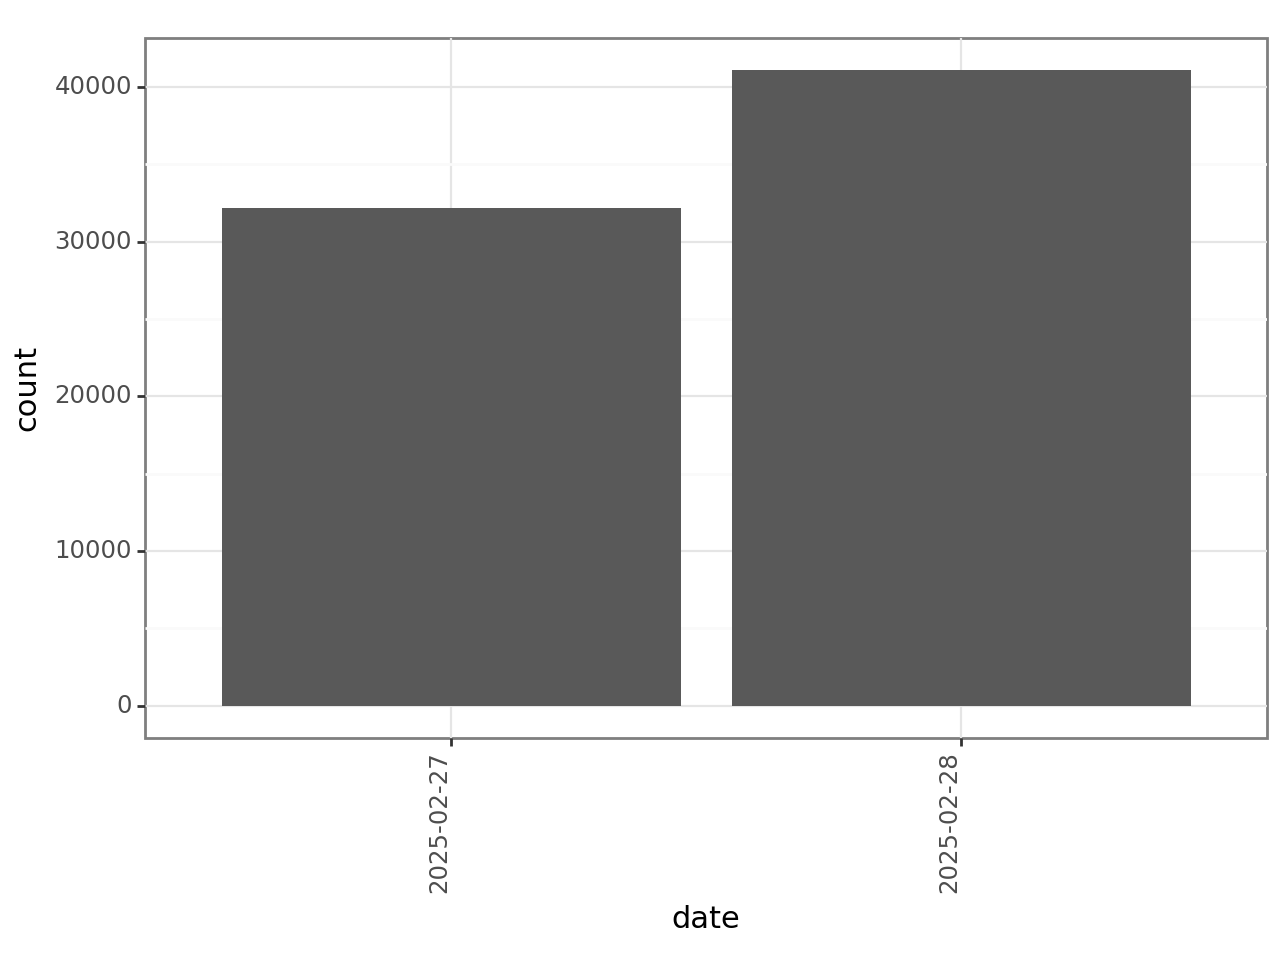

<Figure Size: (640 x 480)>

In [7]:
# plot number of acc finished per day
ggplot(data=s3)+geom_bar(aes(x='date'))+theme(axis_text_x=element_text(rotation=90, hjust=1))

In [8]:
# Are larger files being processed? Plot the number of files processed per day, colored by size
joined = merged20k.join(s3, on='acc', how='left')
joined.filter(pl.col('size')>0)[:3]

acc,releasedate,mbases,mbytes,date,time,size,file,datetime
str,str,i64,i64,str,str,i64,str,datetime[μs]
"""SRR15442735""","""2021-08-13T00:00:00+00:00""",6638,2614,"""2025-02-27""","""16:36:49""",10170,"""SRR15442735.unannotated.single…",2025-02-27 16:36:49
"""ERR1959224""","""2017-07-08T00:00:00+00:00""",8555,3195,"""2025-02-27""","""17:30:39""",1138850,"""ERR1959224.unannotated.singlem…",2025-02-27 17:30:39
"""ERR5003368""","""2020-12-23T00:00:00+00:00""",1013,344,"""2025-02-27""","""16:17:28""",433726,"""ERR5003368.unannotated.singlem…",2025-02-27 16:17:28


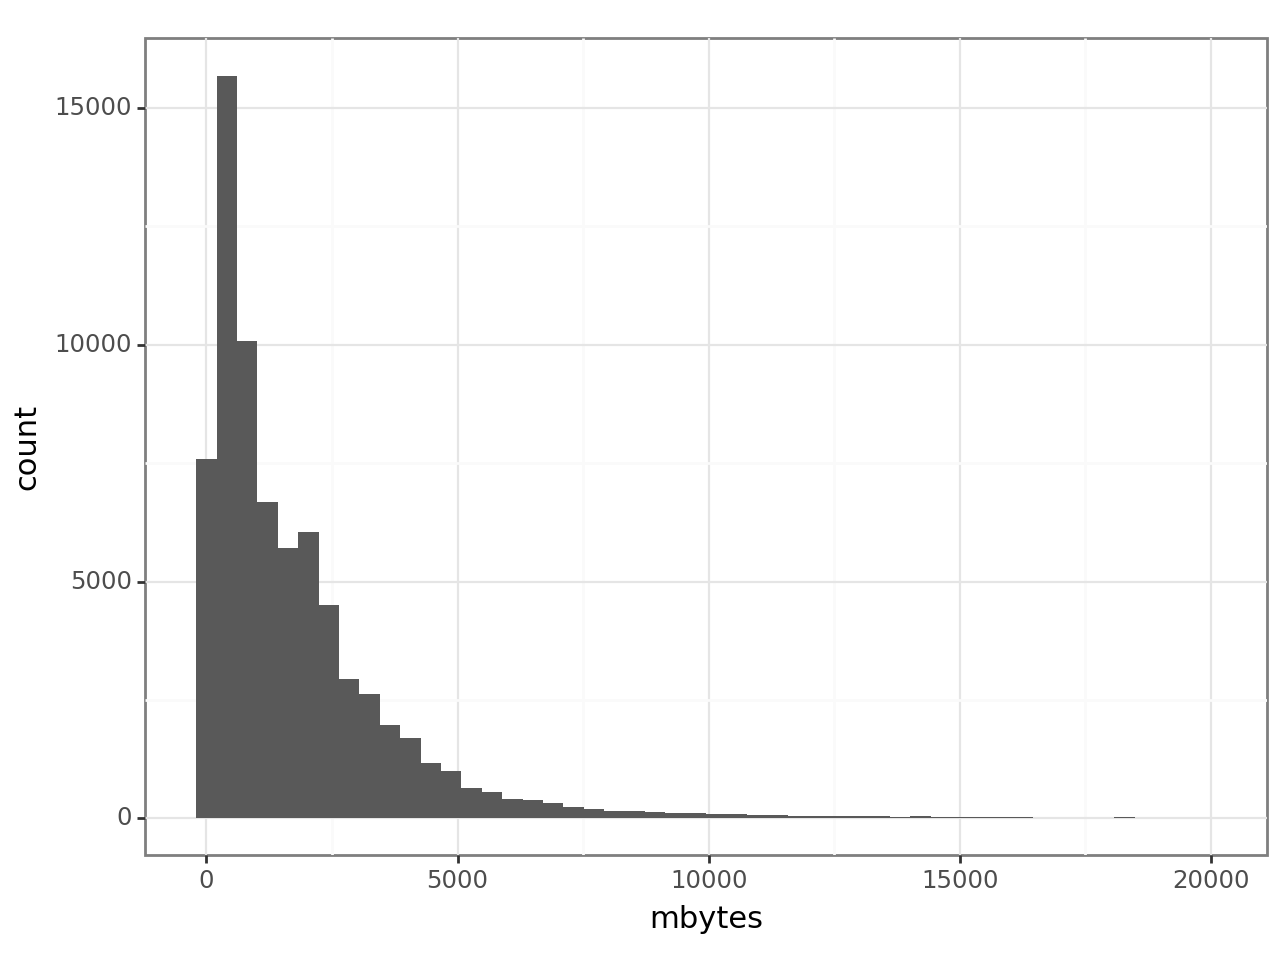

<Figure Size: (640 x 480)>

In [9]:
ggplot(joined.filter(pl.col('size')>0))+geom_histogram(aes(x='mbytes'), bins=50)

shape: (2, 2)
┌───────┬────────┐
│ done  ┆ len    │
│ ---   ┆ ---    │
│ bool  ┆ u32    │
╞═══════╪════════╡
│ true  ┆ 73270  │
│ false ┆ 637658 │
└───────┴────────┘


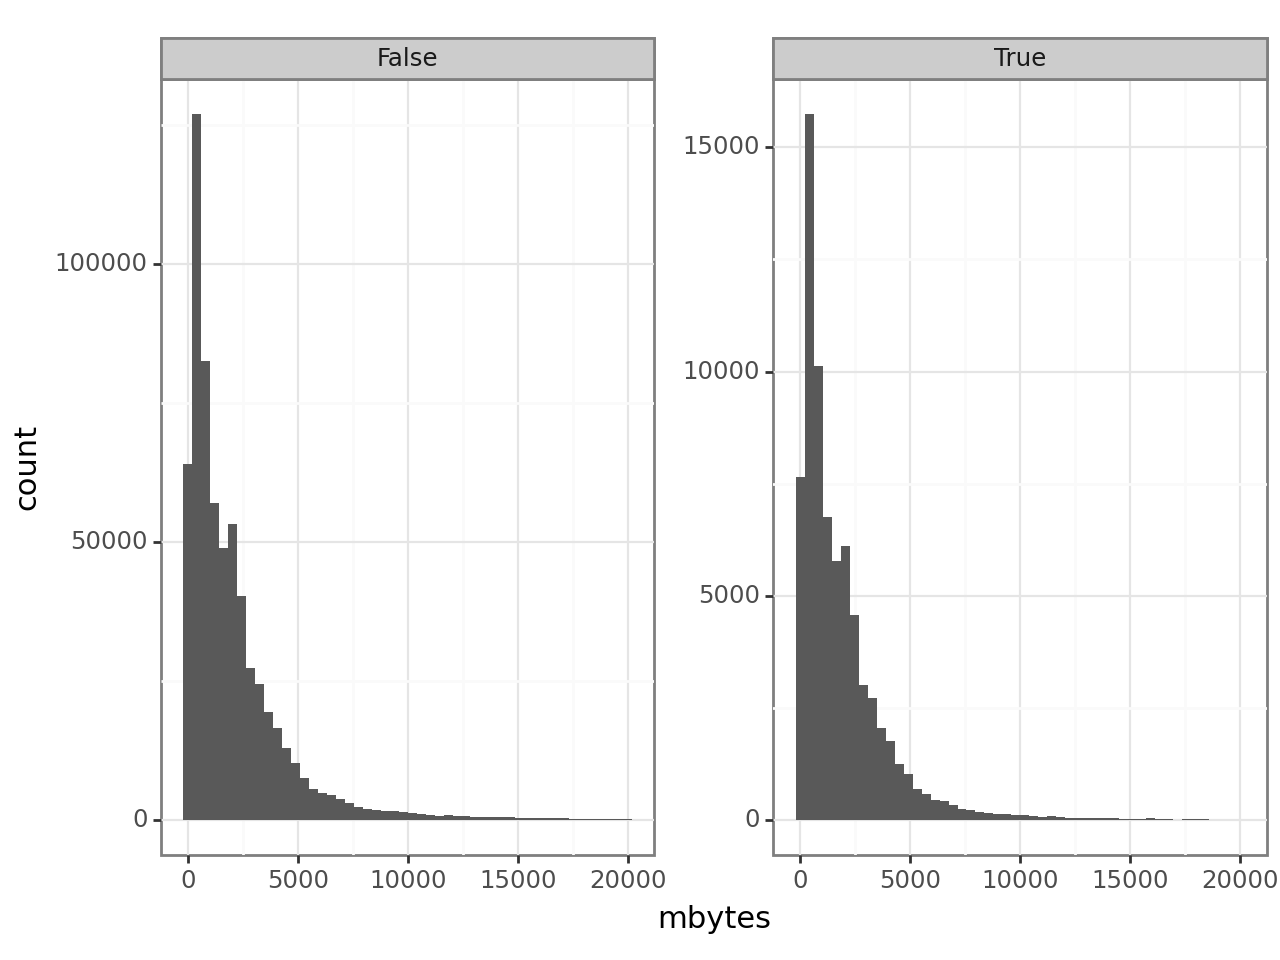

<Figure Size: (640 x 480)>

In [10]:
joined = joined.with_columns(~pl.col('size').is_null().alias('done'))
print(joined.group_by('done').len())
# ggplot(joined)+geom_density(aes(x='mbases'))#, colour='done')
# ggplot(joined.filter(pl.col('done')))+geom_histogram(aes(x='mbytes'), bins=50)
ggplot(joined)+geom_histogram(aes(x='mbytes'), bins=50)+ facet_wrap('done', scales='free_y')

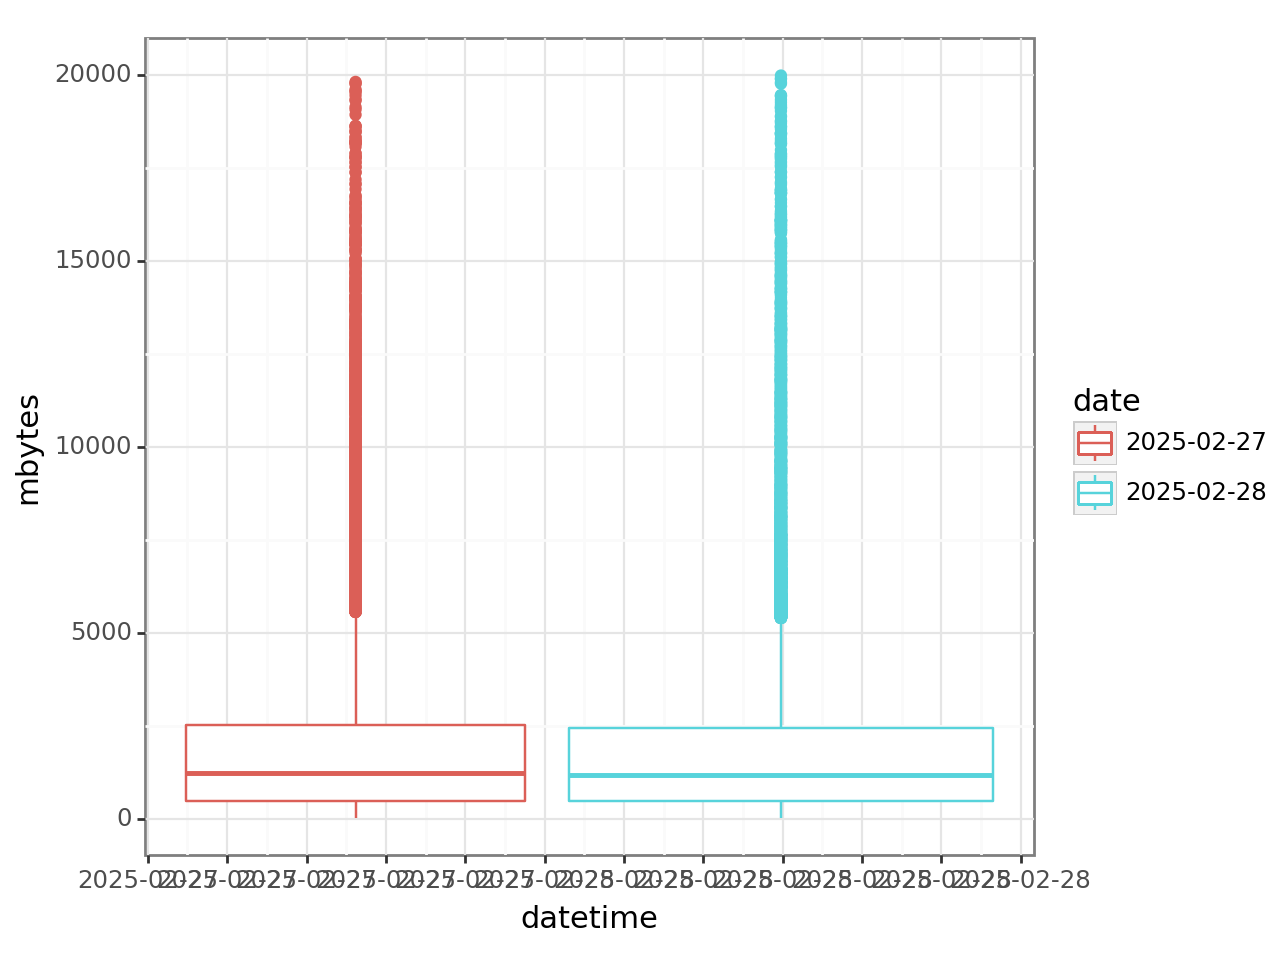

<Figure Size: (640 x 480)>

In [11]:
# Plot size vs date
ggplot(joined.filter(pl.col('done')))+geom_boxplot(aes(x='datetime', y='mbytes', colour='date'))

In [12]:
joined.filter(pl.col('done')).select('date','mbytes').group_by('date').median(), joined.select(pl.col('mbytes')).median()

(shape: (2, 2)
 ┌────────────┬────────┐
 │ date       ┆ mbytes │
 │ ---        ┆ ---    │
 │ str        ┆ f64    │
 ╞════════════╪════════╡
 │ 2025-02-28 ┆ 1175.0 │
 │ 2025-02-27 ┆ 1225.5 │
 └────────────┴────────┘,
 shape: (1, 1)
 ┌────────┐
 │ mbytes │
 │ ---    │
 │ f64    │
 ╞════════╡
 │ 1319.0 │
 └────────┘)

In [13]:
# DONT DO THIS - RAM ISSUES
# # ggplot(joined)+geom_density(aes(x='mbytes', colour='done'))

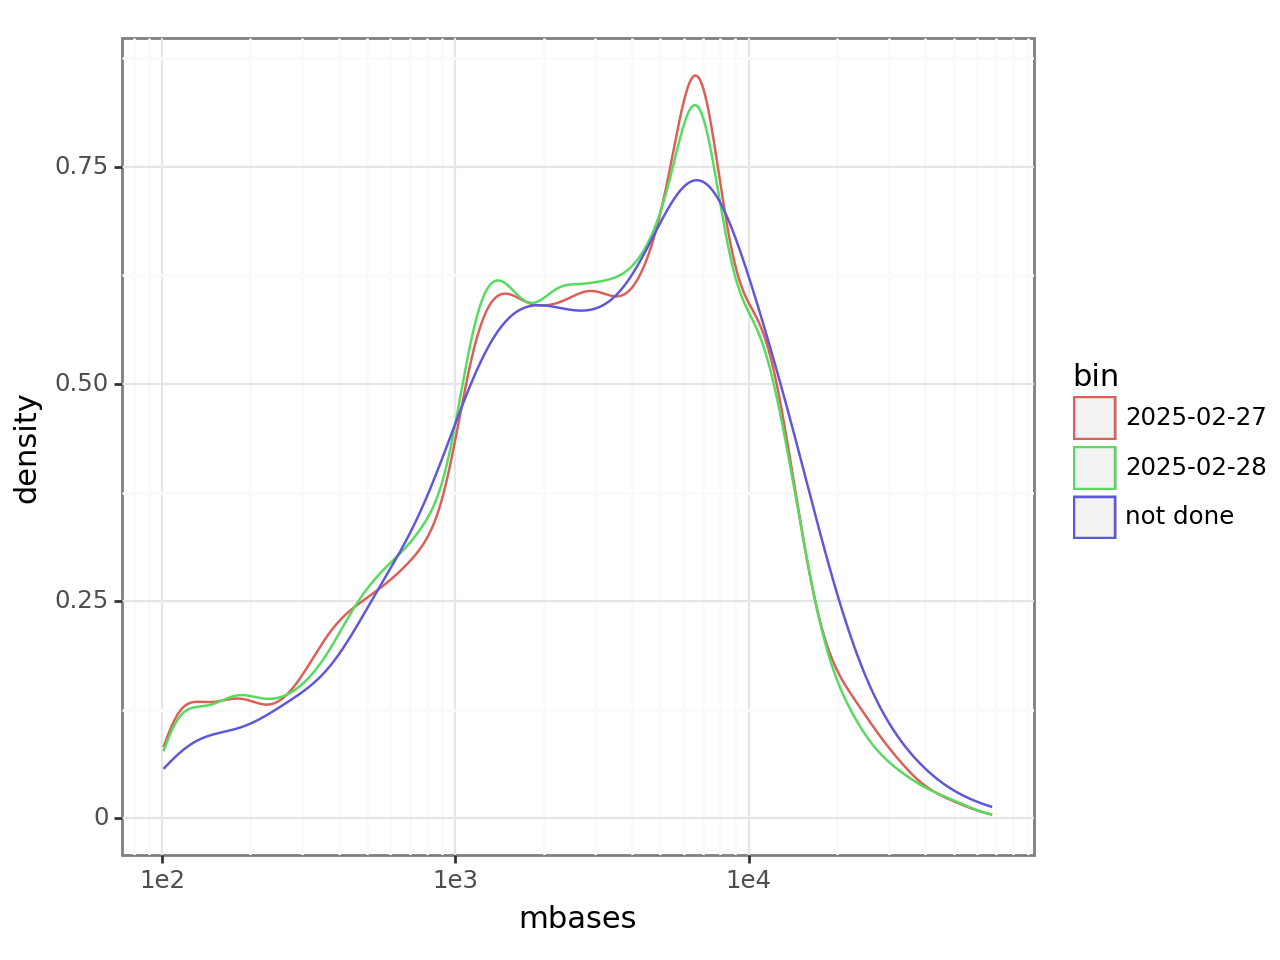

<Figure Size: (640 x 480)>

In [14]:
overall_sample = joined.filter(pl.col('done')==False).sample(1000)

to_plot = pl.concat([overall_sample, joined.filter(pl.col('done'))]).with_columns(pl.when(pl.col('done')==True).then(pl.col('date')).otherwise(pl.lit('not done')).alias('bin'))

to_plot.sample(50)
ggplot(to_plot)+geom_density(aes(x='mbases', colour='bin'))+scale_x_log10()

In [15]:
# estimate total time required to process all files. Time taken is the time since the first file appeared in the S3 bucket
start_time = joined.filter(pl.col('done')).with_columns(pl.col('datetime').min().alias('start'))['start'][0]
# joined.filter(pl.col('datetime')==start_time)
print(start_time)
import datetime
time_since_start = datetime.datetime.now() - start_time
print(time_since_start)
num_to_do = joined.shape[0] - 18831 # minus us-east-2
num_to_do / joined.filter(pl.col('done')).shape[0] * time_since_start, joined.group_by('done').len(), joined.filter(pl.col('done')).shape[0] / num_to_do * 100, joined.filter(pl.col('done')).select('mbases').sum()[0,0] / joined.select('mbases').sum()[0,0] * 100

# but that's an underestimate because smaller files are processed faster, so more likely to be already done.

2025-02-27 09:43:03
20 days, 8:21:43.025874


(datetime.timedelta(days=192, seconds=17967, microseconds=161162),
 shape: (2, 2)
 ┌───────┬────────┐
 │ done  ┆ len    │
 │ ---   ┆ ---    │
 │ bool  ┆ u32    │
 ╞═══════╪════════╡
 │ true  ┆ 73270  │
 │ false ┆ 637658 │
 └───────┴────────┘,
 10.586666319894466,
 9.283281209222881)

In [16]:
(412005+119021+18831)/df.shape[0], (471178+119021+18831)/df.shape[0]

(0.702060124743841, 0.7776125024738095)

In [17]:
df.filter(pl.col('mbases') >= 8000).sample(5)

acc,releasedate,mbases,mbytes
str,str,i64,i64
"""SRR22388173""","""2024-07-22T00:00:00+00:00""",36293,10598
"""SRR27128306""","""2023-12-07T00:00:00+00:00""",9773,2969
"""SRR816402""","""2014-02-13T00:00:00+00:00""",22285,13321
"""SRR27477469""","""2025-01-02T00:00:00+00:00""",9854,3042
"""SRR25571374""","""2023-09-30T00:00:00+00:00""",14050,4622


In [18]:
# How many GBytes of data >= 8000 ? A lot...
df.filter(pl.col('mbases') >= 8000).select('mbytes').sum()[0,0] / 1e6, df.filter(pl.col('mbases') < 8000).select('mbytes').sum()[0,0] / 1e6, df.filter(pl.col('mbases') > 50000).select('mbytes').sum()[0,0] / 1e6

(1099.691055, 663.890644, 145.034145)

In [19]:
# How many runs?
df.filter(pl.col('mbases') >= 8000).shape[0] / df.shape[0], df.filter(pl.col('mbases') >= 50000).shape[0] / df.shape[0]

(0.2386361169808671, 0.007150107570814793)

# Size of s3 so far

In [20]:
# Try those < 8gbases again where they failed - maybe the increased RAM of a this batch will get them through?
import extern
extern.run('cat s3_ls/* |grep RR |sed "s/  */\t/g" >/tmp/runs')

prev4 = pl.read_csv('/tmp/runs', has_header=False, separator='\t')
prev4.columns = ["acc", "time", "size", "path"]
print(prev4.group_by(pl.col('size') > 0).len())
prev5 = prev4.filter(pl.col('size') > 0).with_columns(pl.col("path").alias("acc").str.split('.').list.get(0))
prev5.shape, prev5.select(pl.col('size').sum())[0,0] / 1e9

shape: (2, 2)
┌───────┬────────┐
│ size  ┆ len    │
│ ---   ┆ ---    │
│ bool  ┆ u32    │
╞═══════╪════════╡
│ false ┆ 8769   │
│ true  ┆ 591446 │
└───────┴────────┘


((591446, 4), 330.521209244)

# How many human metagenomes? Seems a lot

In [21]:
with_human = pl.read_csv('~/git/sandpiper/sra_metadata/sra_metadata_20250220.some_columns2.csv.gz', has_header=False)
with_human.columns = ['acc','releasedate','mbases','mbytes','organism']
with_human.shape, with_human[:3]

((783205, 5),
 shape: (3, 5)
 ┌─────────────┬───────────────────────────┬────────┬────────┬──────────────────┐
 │ acc         ┆ releasedate               ┆ mbases ┆ mbytes ┆ organism         │
 │ ---         ┆ ---                       ┆ ---    ┆ ---    ┆ ---              │
 │ str         ┆ str                       ┆ i64    ┆ i64    ┆ str              │
 ╞═════════════╪═══════════════════════════╪════════╪════════╪══════════════════╡
 │ SRR15442735 ┆ 2021-08-13T00:00:00+00:00 ┆ 6638   ┆ 2614   ┆ viral metagenome │
 │ ERR1959224  ┆ 2017-07-08T00:00:00+00:00 ┆ 8555   ┆ 3195   ┆ feces metagenome │
 │ ERR5003368  ┆ 2020-12-23T00:00:00+00:00 ┆ 1013   ┆ 344    ┆ gut metagenome   │
 └─────────────┴───────────────────────────┴────────┴────────┴──────────────────┘)

In [22]:
with_human = with_human.with_columns((pl.col('organism').str.contains('gut') | pl.col('organism').str.contains('feces') | pl.col('organism').str.contains('human')).alias('is_human'))
humans = with_human.filter(pl.col('is_human'))
with_human.shape, with_human[:3], humans.shape[0], with_human.filter(~pl.col('is_human')).shape[0], humans.shape[0] / with_human.shape[0] * 100

((783205, 6),
 shape: (3, 6)
 ┌─────────────┬───────────────────────────┬────────┬────────┬──────────────────┬──────────┐
 │ acc         ┆ releasedate               ┆ mbases ┆ mbytes ┆ organism         ┆ is_human │
 │ ---         ┆ ---                       ┆ ---    ┆ ---    ┆ ---              ┆ ---      │
 │ str         ┆ str                       ┆ i64    ┆ i64    ┆ str              ┆ bool     │
 ╞═════════════╪═══════════════════════════╪════════╪════════╪══════════════════╪══════════╡
 │ SRR15442735 ┆ 2021-08-13T00:00:00+00:00 ┆ 6638   ┆ 2614   ┆ viral metagenome ┆ false    │
 │ ERR1959224  ┆ 2017-07-08T00:00:00+00:00 ┆ 8555   ┆ 3195   ┆ feces metagenome ┆ true     │
 │ ERR5003368  ┆ 2020-12-23T00:00:00+00:00 ┆ 1013   ┆ 344    ┆ gut metagenome   ┆ true     │
 └─────────────┴───────────────────────────┴────────┴────────┴──────────────────┴──────────┘,
 386772,
 395778,
 49.383239381771055)

In [23]:
with_human = with_human.with_columns(pl.col('releasedate').str.to_datetime("%Y-%m-%dT00:00:00+00:00").alias('year').dt.year())
by_year = with_human.group_by('is_human', 'year').len()
by_year[:4]

is_human,year,len
bool,i32,u32
true,2016,8282
true,2015,10854
false,2017,15509
true,2024,110166


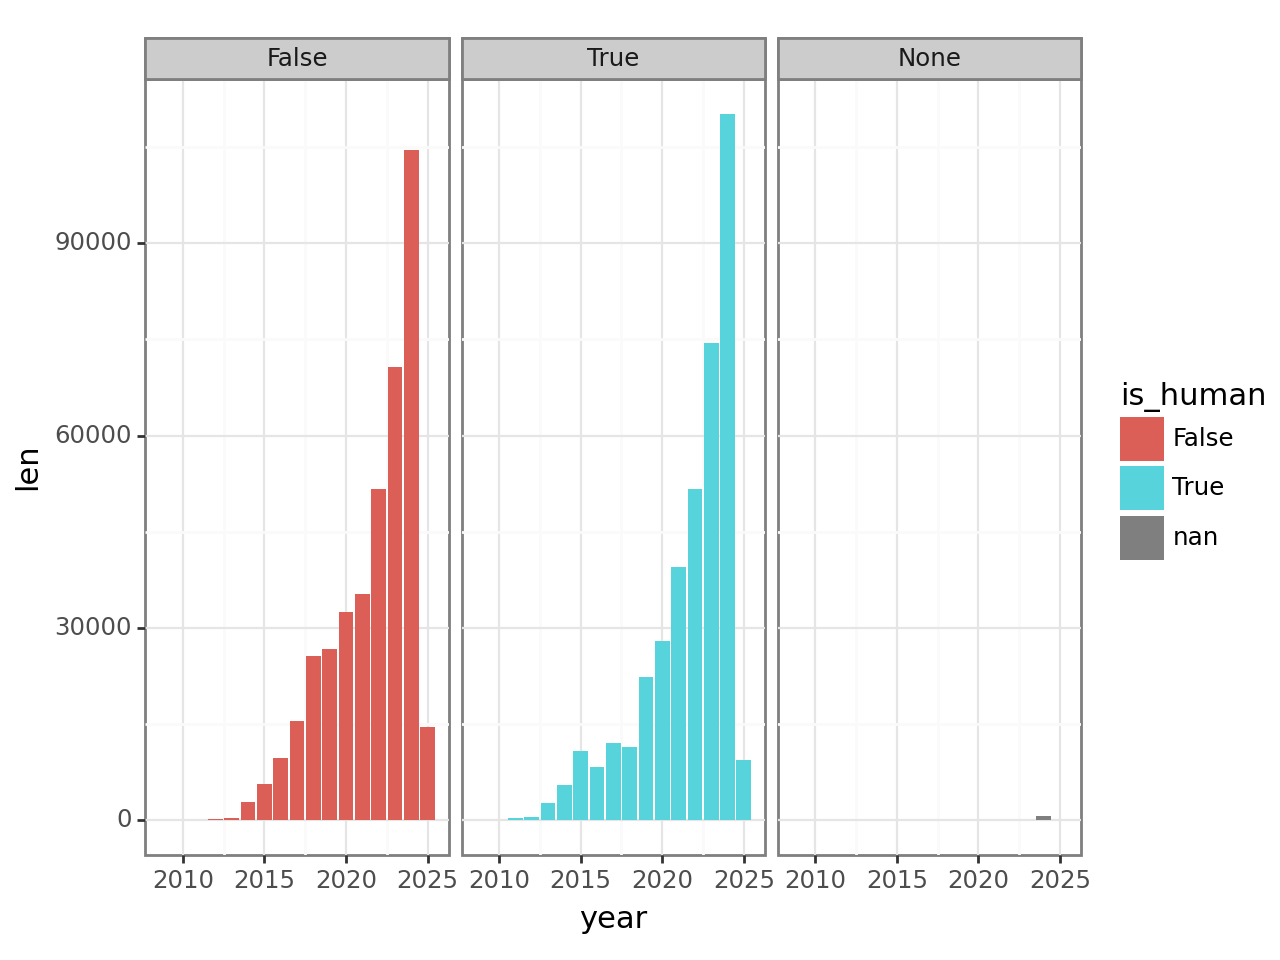

<Figure Size: (640 x 480)>

In [24]:
ggplot(by_year)+geom_bar(aes(x='year', y='len', fill='is_human'), stat='identity') + facet_wrap('is_human')

/home/ben/e/mybase/lib/python3.11/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


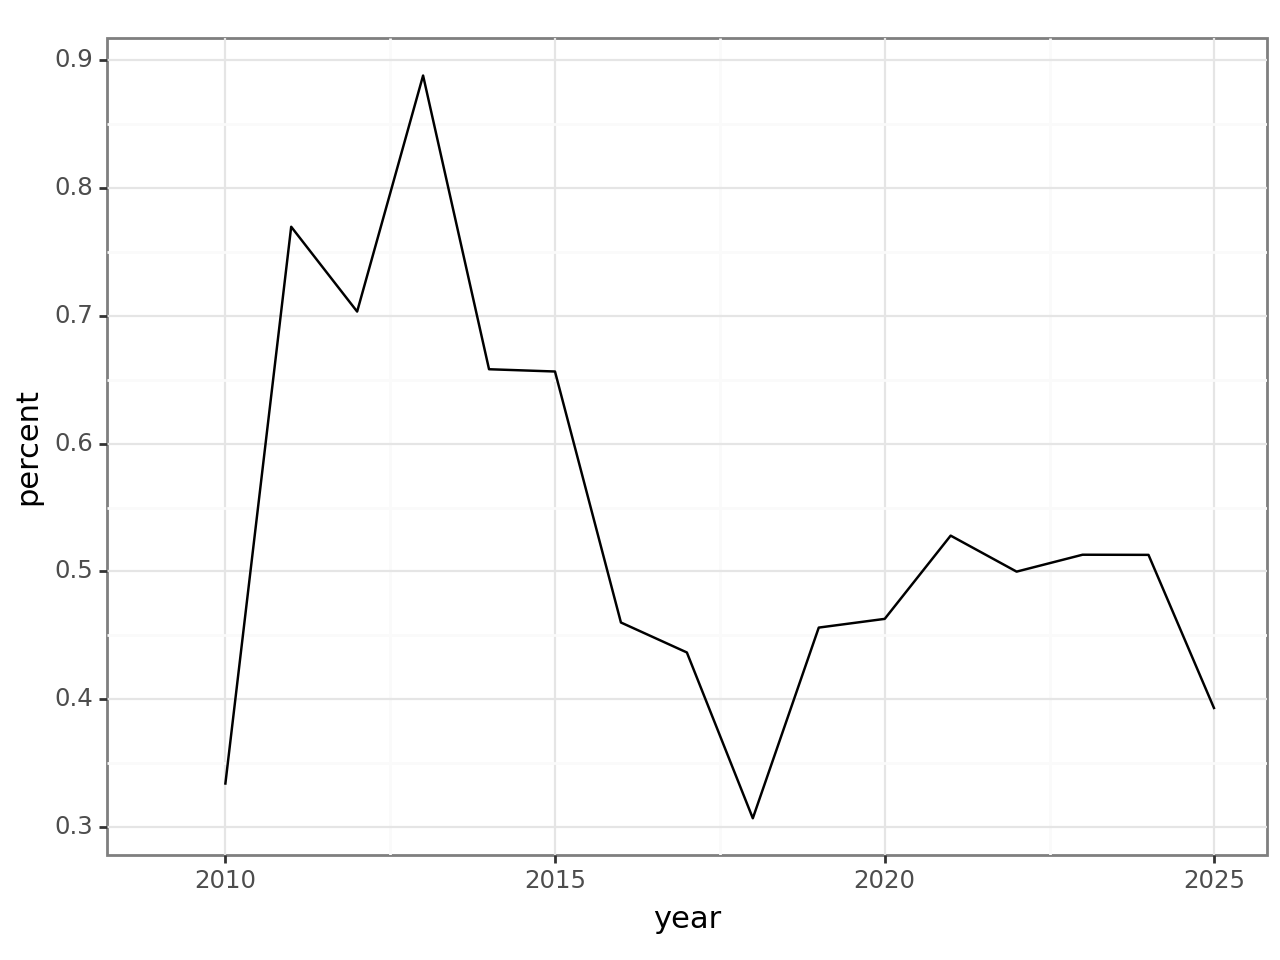

<Figure Size: (640 x 480)>

In [25]:
by_year2 = by_year.pivot('is_human', values='len')#, 'year', 'len')
by_year2 = by_year2.with_columns((pl.col('true') / (pl.col('true') + pl.col('false'))).alias('percent'))
ggplot(by_year2) + geom_line(aes(x='year', y='percent'))

In [26]:
with_human.sample(10)

acc,releasedate,mbases,mbytes,organism,is_human,year
str,str,i64,i64,str,bool,i32
"""ERR4369761""","""2021-06-22T00:00:00+00:00""",458,191,"""mouse gut metagenome""",true,2021
"""ERR719972""","""2015-06-18T00:00:00+00:00""",808,514,"""gut metagenome""",true,2015
"""SRR13296317""","""2020-12-23T00:00:00+00:00""",2143,916,"""soil metagenome""",false,2020
"""SRR13348814""","""2021-06-23T00:00:00+00:00""",5081,1661,"""metagenome""",false,2021
"""ERR13712528""","""2024-09-26T00:00:00+00:00""",2479,706,"""wastewater metagenome""",false,2024
"""SRR28055700""","""2024-02-22T00:00:00+00:00""",7326,2415,"""gut metagenome""",true,2024
"""SRR17780063""","""2023-07-24T00:00:00+00:00""",1316,526,"""human feces metagenome""",true,2023
"""SRR21285571""","""2023-01-01T00:00:00+00:00""",21851,9365,"""metagenome""",false,2023
"""SRR27905934""","""2024-02-07T00:00:00+00:00""",3139,980,"""wastewater metagenome""",false,2024


/home/ben/e/mybase/lib/python3.11/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


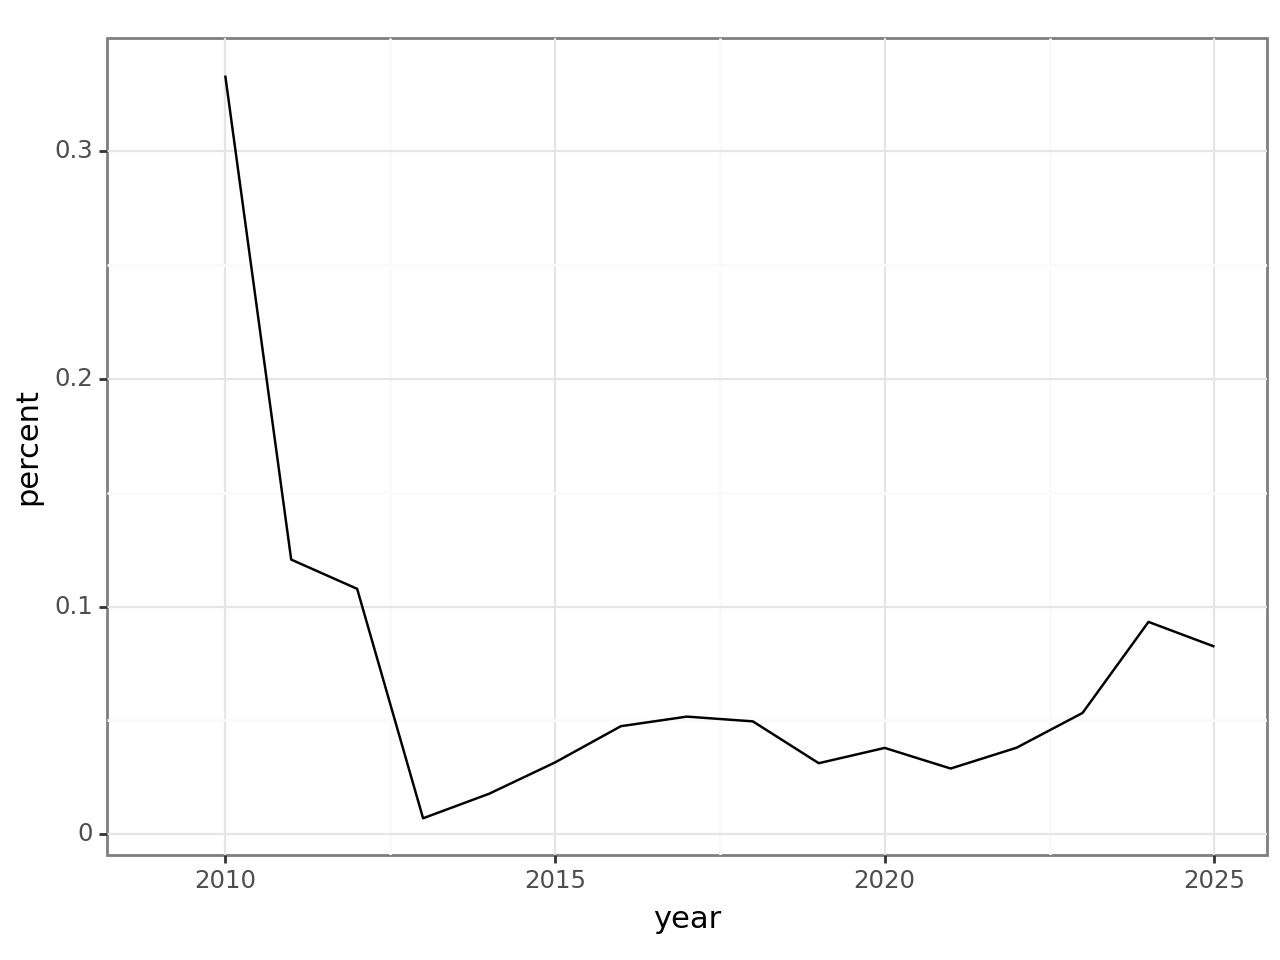

<Figure Size: (640 x 480)>

In [27]:
# soil metagenomes over time
soil_by_year = with_human.group_by(('year', pl.col('organism').str.contains('soil').alias('soil'))).len()
soil_by_year2 = soil_by_year.pivot('soil', values='len')
soil_by_year2 = soil_by_year2.with_columns((pl.col('true') / (pl.col('false')+pl.col('true'))).alias('percent'))
ggplot(soil_by_year2) + geom_line(aes(x='year', y='percent'))

/home/ben/e/mybase/lib/python3.11/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 2 rows containing missing values.


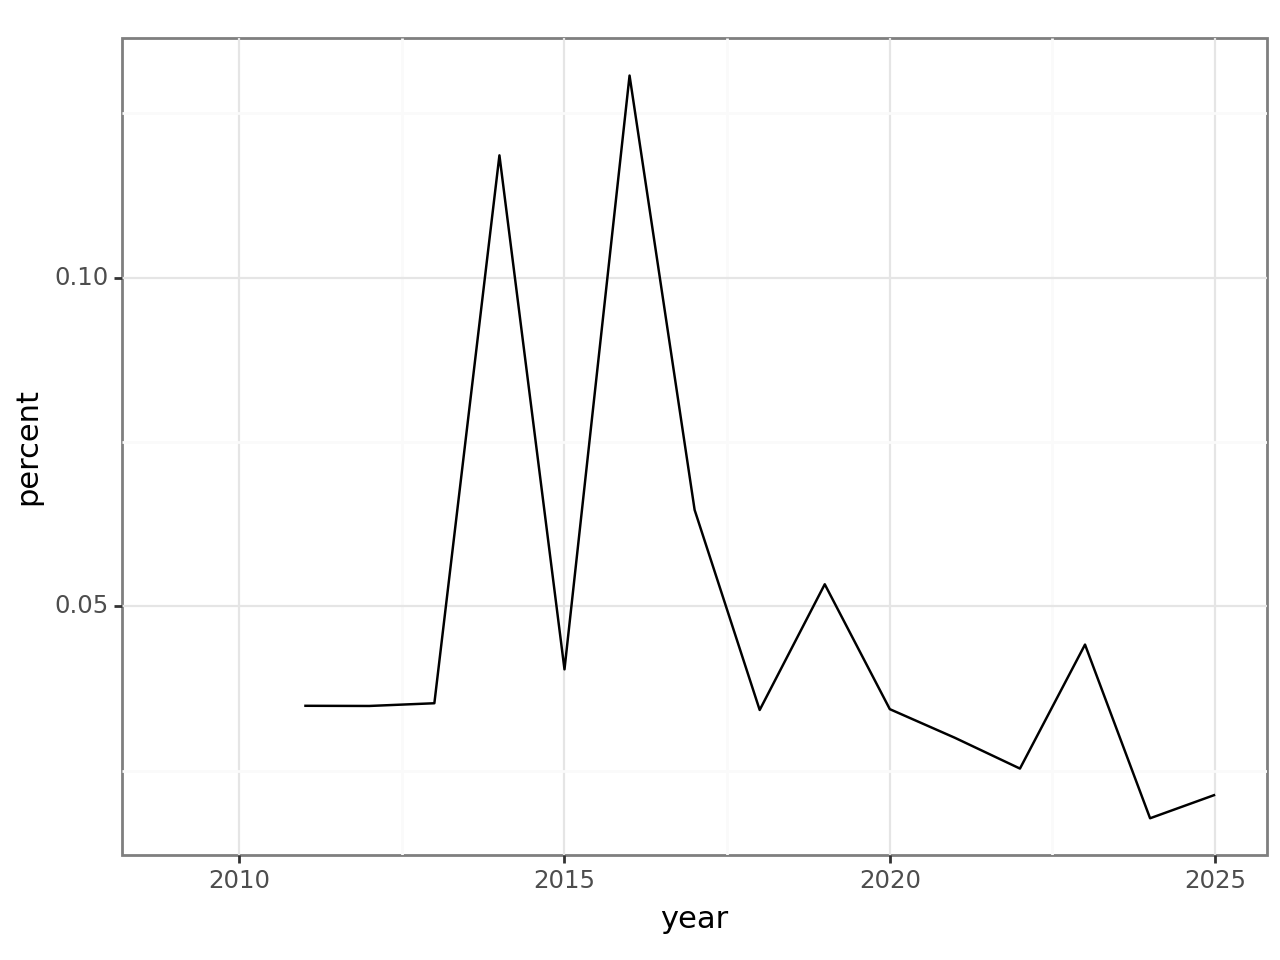

<Figure Size: (640 x 480)>

In [28]:
# marine
soil_by_year = with_human.group_by(('year', pl.col('organism').str.contains('marine').alias('soil'))).len()
soil_by_year2 = soil_by_year.pivot('soil', values='len')
soil_by_year2 = soil_by_year2.with_columns((pl.col('true') / (pl.col('false')+pl.col('true'))).alias('percent'))
ggplot(soil_by_year2) + geom_line(aes(x='year', y='percent'))

/home/ben/e/mybase/lib/python3.11/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


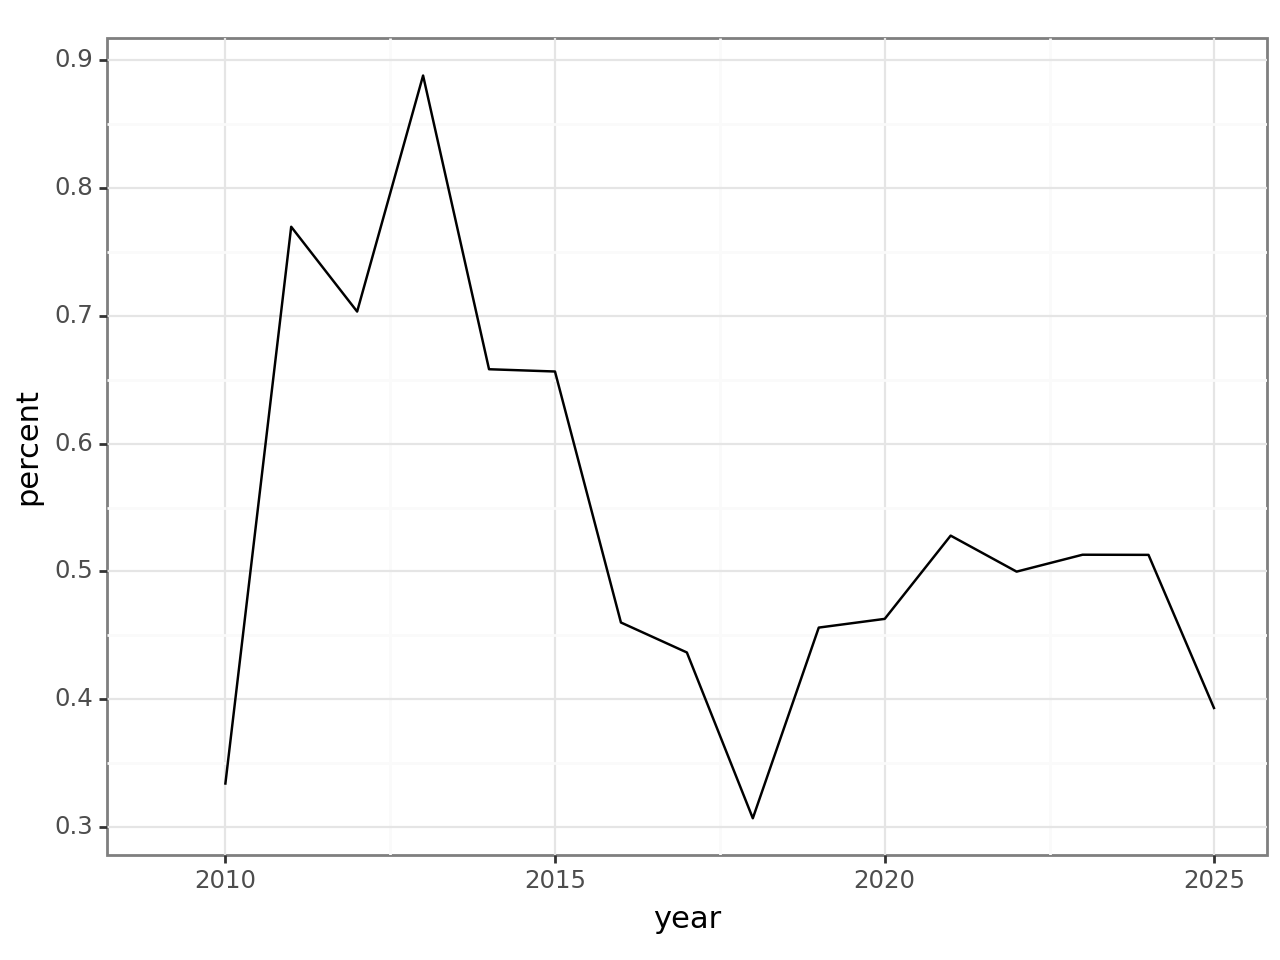

<Figure Size: (640 x 480)>

In [29]:
# human metagenomes over time
soil_by_year = with_human.group_by(('year', (pl.col('organism').str.contains('gut') | pl.col('organism').str.contains('feces') | pl.col('organism').str.contains('human')).alias('soil'))).len()
soil_by_year2 = soil_by_year.pivot('soil', values='len')
soil_by_year2 = soil_by_year2.with_columns((pl.col('true') / (pl.col('false')+pl.col('true'))).alias('percent'))
ggplot(soil_by_year2) + geom_line(aes(x='year', y='percent'))

In [30]:
with_human.filter(pl.col('year')==2013).group_by('is_human').len()

is_human,len
bool,u32
true,2670
false,338


In [31]:
# Are bigger metagenomes less likely to be human? A bit, yeh. Good.
with_human.select('is_human',pl.col('mbases')>8000).group_by('is_human','mbases').len()

is_human,mbases,len
bool,bool,u32
false,false,288544
false,true,107234
true,true,79067
true,false,307705
null,false,84
null,true,571


# Runtimes for batch 12 8 to 30GB

In [32]:
def show_all(df, width=200, max_col_width=True):
    '''
    Prints an entire polars dataframe in the console or notebook output.
    Parameters
    ----------
    df : pl.DataFrame
        The dataframe to be printed.
    width : int, optional
        The width of the printed dataframe.
        Defaults to 200.
    max_col_width : bool, optional
        Whether to set the maximum column width.
        i.e. it will print the full contents of the cells.
        Defaults to True.
    '''
    with  pl.Config()  as  cfg:
        cfg.set_tbl_cols(-1)
        cfg.set_tbl_rows(-1)
        cfg.set_tbl_width_chars(width)
        if  max_col_width  or  len(df.columns) ==  1:
            cfg.set_fmt_str_lengths(width)
        print(df)

In [33]:
# First run:
#
# ben in 🌐 b2 in singlem-sra-processing/cloud/argo on  main [!?] via 🐍 v3.11.3 via mybase 20250314 took 3s 
# ➜  rclone sync aws-s3:woodcrob-sandpiper-us-east-1/logs5 logs

# ➜  cat logs/SRR25018333.log
# 03/14/2025 02:04:14 AM INFO: Kingfisher v0.4.1
# 03/14/2025 02:04:14 AM INFO: Attempting download method aws-http for run SRR25018333 ..
# 03/14/2025 02:04:14 AM INFO: Guessing AWS-ODP link to be: https://sra-pub-run-odp.s3.amazonaws.com/sra/SRR25018333/SRR25018333
# 03/14/2025 02:04:14 AM INFO: Downloading .SRA file from AWS Open Data Program HTTP link using aria2c ..
# 03/14/2025 02:04:46 AM INFO: Download finished, validating ..
# 03/14/2025 02:04:46 AM INFO: Method aws-http worked.
# 03/14/2025 02:04:46 AM INFO: Output files: /SRR25018333.sra
# 03/14/2025 02:04:46 AM INFO: Kingfisher done.
# 03/14/2025 02:04:47 AM INFO: SingleM v0.18.3.post1.8f3a89d7
# 03/14/2025 02:04:47 AM INFO: Loaded 125 SingleM packages
# 03/14/2025 02:04:47 AM INFO: Using as input 1 different .SRA format sequence files e.g. SRR25018333.sra
# 03/14/2025 02:04:47 AM INFO: Filtering sequence files through DIAMOND blastx
# 03/14/2025 02:13:37 AM INFO: Finished DIAMOND prefilter phase
# 03/14/2025 02:13:37 AM INFO: Assigning sequences to SingleM packages with DIAMOND ..
# 03/14/2025 02:14:23 AM INFO: Finished

import extern

def get_step(grep_str, step_name):
    extern.run(f'grep "{grep_str}" logs/* >/tmp/readme')
    df = pl.read_csv('/tmp/readme', has_header=False, separator=' ')
    # First 3 cols
    df = df.select('column_1', 'column_2', 'column_3')
    df.columns = ['acc_date', 'time', 'am_pm']#, 'blah1', 'blah2', 'blah3']
    df = df.with_columns((pl.col('acc_date').str.split(':').list.get(1) + ' ' + pl.col('time') + ' ' + pl.col('am_pm')).str.to_datetime("%m/%d/%Y %I:%M:%S %p").alias(step_name))
    df = df.with_columns(pl.col('acc_date').str.split(':').list.get(0).alias('acc').str.replace('.log', '').str.split('/').list.get(-1))
    df = df.select('acc',step_name)#.with_columns(pl.lit(step_name).alias('step'))
    return df

kingfisher_starts = get_step('Kingfisher v0.4.1', 'Kingfisher_start')
kingfisher_done = get_step('Kingfisher done', 'Kingfisher_done')
diamond_done = get_step('Finished DIAMOND prefilter phase', 'Diamond_done')
singlem_done = get_step('INFO: Finished$', 'SingleM_done')

merge = kingfisher_starts.join(kingfisher_done, on='acc', how='inner').join(diamond_done, on='acc', how='inner').join(singlem_done, on='acc', how='inner')
merge = merge.with_columns((pl.col('SingleM_done') - pl.col('Kingfisher_start')).alias('time'))
merge = merge.join(with_human, on='acc', how='inner')
merge.shape, merge[:3]

((43, 12),
 shape: (3, 12)
 ┌─────────────┬─────────────┬─────────────┬────────────┬───┬────────┬────────────┬──────────┬──────┐
 │ acc         ┆ Kingfisher_ ┆ Kingfisher_ ┆ Diamond_do ┆ … ┆ mbytes ┆ organism   ┆ is_human ┆ year │
 │ ---         ┆ start       ┆ done        ┆ ne         ┆   ┆ ---    ┆ ---        ┆ ---      ┆ ---  │
 │ str         ┆ ---         ┆ ---         ┆ ---        ┆   ┆ i64    ┆ str        ┆ bool     ┆ i32  │
 │             ┆ datetime[μs ┆ datetime[μs ┆ datetime[μ ┆   ┆        ┆            ┆          ┆      │
 │             ┆ ]           ┆ ]           ┆ s]         ┆   ┆        ┆            ┆          ┆      │
 ╞═════════════╪═════════════╪═════════════╪════════════╪═══╪════════╪════════════╪══════════╪══════╡
 │ SRR26864521 ┆ 2025-03-14  ┆ 2025-03-14  ┆ 2025-03-14 ┆ … ┆ 5067   ┆ Triticum   ┆ false    ┆ 2023 │
 │             ┆ 02:27:26    ┆ 02:28:01    ┆ 02:41:32   ┆   ┆        ┆ aestivum   ┆          ┆      │
 │ SRR30025082 ┆ 2025-03-14  ┆ 2025-03-14  ┆ 2025-03-14

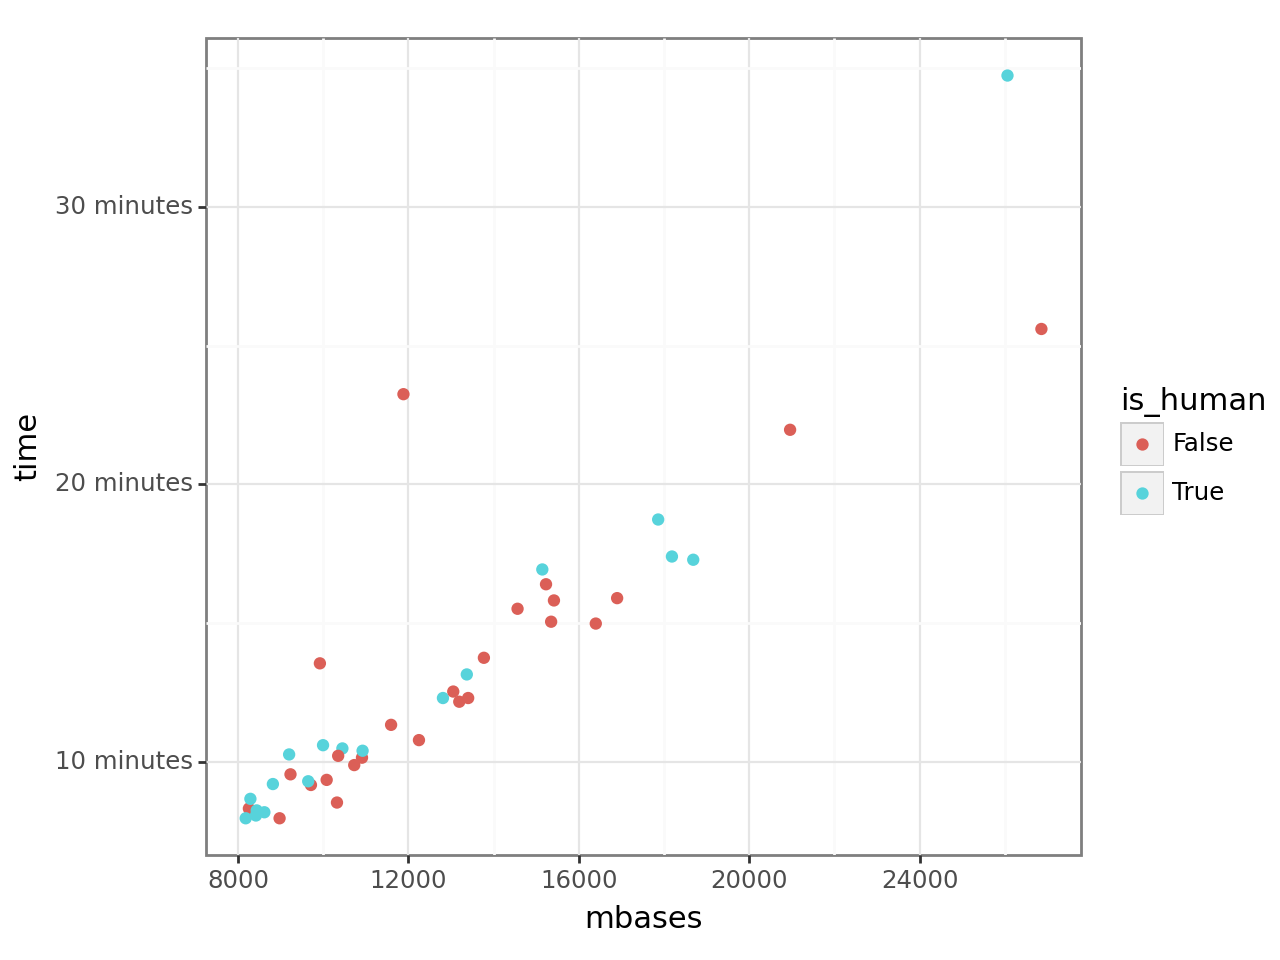

<Figure Size: (640 x 480)>

In [34]:
ggplot(merge)+geom_point(aes(x='mbases', y='time', colour='is_human'))

In [35]:
merge.sample(3)

acc,Kingfisher_start,Kingfisher_done,Diamond_done,SingleM_done,time,releasedate,mbases,mbytes,organism,is_human,year
str,datetime[μs],datetime[μs],datetime[μs],datetime[μs],duration[μs],str,i64,i64,str,bool,i32
"""SRR16297622""",2025-03-14 02:14:03,2025-03-14 02:14:38,2025-03-14 02:28:10,2025-03-14 02:29:57,15m 54s,"""2021-10-12T00:00:00+00:00""",16899,5236,"""groundwater metagenome""",false,2021
"""SRR30025082""",2025-03-14 02:42:48,2025-03-14 02:43:34,2025-03-14 02:58:52,2025-03-14 03:00:12,17m 24s,"""2024-10-09T00:00:00+00:00""",18185,6027,"""human gut metagenome""",true,2024
"""SRR31480333""",2025-03-14 02:16:19,2025-03-14 02:16:58,2025-03-14 02:30:22,2025-03-14 02:32:08,15m 49s,"""2024-12-03T00:00:00+00:00""",15416,4650,"""seawater metagenome""",false,2024


In [36]:
# So given that response curve, what is the total tim required for this? sane?
list(merge['mbases'])

from sklearn.linear_model import LinearRegression
import numpy as np
np.array(merge['mbases']).reshape(-1, 1)

model = LinearRegression()
model.fit(
    np.array(merge['mbases']).reshape(-1, 1), 
    np.array(merge.select(pl.col('time').dt.total_seconds())).reshape(-1, 1)
)
    # list[merge['time']])

a = model.intercept_[0]
b = model.coef_[0][0]
print(f"Intercept (a): {a}, Slope (b): {b}")

with_human = with_human.with_columns((pl.col('mbases')*b+a).alias('time_8cpus'))
with_human.filter(pl.col('acc')=='ERR11504083')['time_8cpus'][0] / 60 # real was 8m 15s


Intercept (a): -62.342097271427065, Slope (b): 0.0663205200669607


8.290051534895353

In [37]:
hours8to30_total = with_human.filter(pl.col('mbases')>=8000).filter(pl.col('mbases')<30000).select('time_8cpus').sum()[0,0] / 60 / 60
hours8to30_total / 10 / 40 / 24 # 10 at a time, on 40 nodes, converted to days
#=> 4 days. So 4 days to process all the 8-30gbases files, fine by me I think. Nice.

4.039693519211003

In [38]:
# What about 30+ ?
hours30plus_total = with_human.filter(pl.col('mbases')>=30000).select('time_8cpus').sum()[0,0] / 60 / 60
hours30plus_total / 10 / 40 / 24 # 10 at a time, on 40 nodes, converted to days
#=> 1.5 days. So 1.5 days to process all the 30+gbases files. Might need to up the CPUs so they run in a shorter time, though, to avoid the hammer of spot instances.

1.5777940813960543

# batch 13

In [41]:
def get_step(grep_str, step_name):
    extern.run(f'grep "{grep_str}" logs6/* >/tmp/readme')
    df = pl.read_csv('/tmp/readme', has_header=False, separator=' ')
    # First 3 cols
    df = df.select('column_1', 'column_2', 'column_3')
    df.columns = ['acc_date', 'time', 'am_pm']#, 'blah1', 'blah2', 'blah3']
    df = df.with_columns((pl.col('acc_date').str.split(':').list.get(1) + ' ' + pl.col('time') + ' ' + pl.col('am_pm')).str.to_datetime("%m/%d/%Y %I:%M:%S %p").alias(step_name))
    df = df.with_columns(pl.col('acc_date').str.split(':').list.get(0).alias('acc').str.replace('.log', '').str.split('/').list.get(-1))
    df = df.select('acc',step_name)#.with_columns(pl.lit(step_name).alias('step'))
    return df

kingfisher_starts = get_step('Kingfisher v0.4.1', 'Kingfisher_start')
kingfisher_done = get_step('Kingfisher done', 'Kingfisher_done')
diamond_done = get_step('Finished DIAMOND prefilter phase', 'Diamond_done')
singlem_done = get_step('INFO: Finished$', 'SingleM_done')

merge = kingfisher_starts.join(kingfisher_done, on='acc', how='inner').join(diamond_done, on='acc', how='inner').join(singlem_done, on='acc', how='inner')
merge = merge.with_columns((pl.col('SingleM_done') - pl.col('Kingfisher_start')).alias('time'))
merge = merge.join(with_human, on='acc', how='inner')
merge.shape, merge[:3]

((1238, 13),
 shape: (3, 13)
 ┌────────────┬────────────┬────────────┬────────────┬───┬────────────┬──────────┬──────┬───────────┐
 │ acc        ┆ Kingfisher ┆ Kingfisher ┆ Diamond_do ┆ … ┆ organism   ┆ is_human ┆ year ┆ time_8cpu │
 │ ---        ┆ _start     ┆ _done      ┆ ne         ┆   ┆ ---        ┆ ---      ┆ ---  ┆ s         │
 │ str        ┆ ---        ┆ ---        ┆ ---        ┆   ┆ str        ┆ bool     ┆ i32  ┆ ---       │
 │            ┆ datetime[μ ┆ datetime[μ ┆ datetime[μ ┆   ┆            ┆          ┆      ┆ f64       │
 │            ┆ s]         ┆ s]         ┆ s]         ┆   ┆            ┆          ┆      ┆           │
 ╞════════════╪════════════╪════════════╪════════════╪═══╪════════════╪══════════╪══════╪═══════════╡
 │ DRR597820  ┆ 2025-03-19 ┆ 2025-03-19 ┆ 2025-03-19 ┆ … ┆ Homo       ┆ false    ┆ 2024 ┆ 7665.3912 │
 │            ┆ 03:47:00   ┆ 03:52:41   ┆ 05:09:38   ┆   ┆ sapiens    ┆          ┆      ┆ 21        │
 │ SRR3715698 ┆ 2025-03-19 ┆ 2025-03-19 ┆ 2025-03-19 

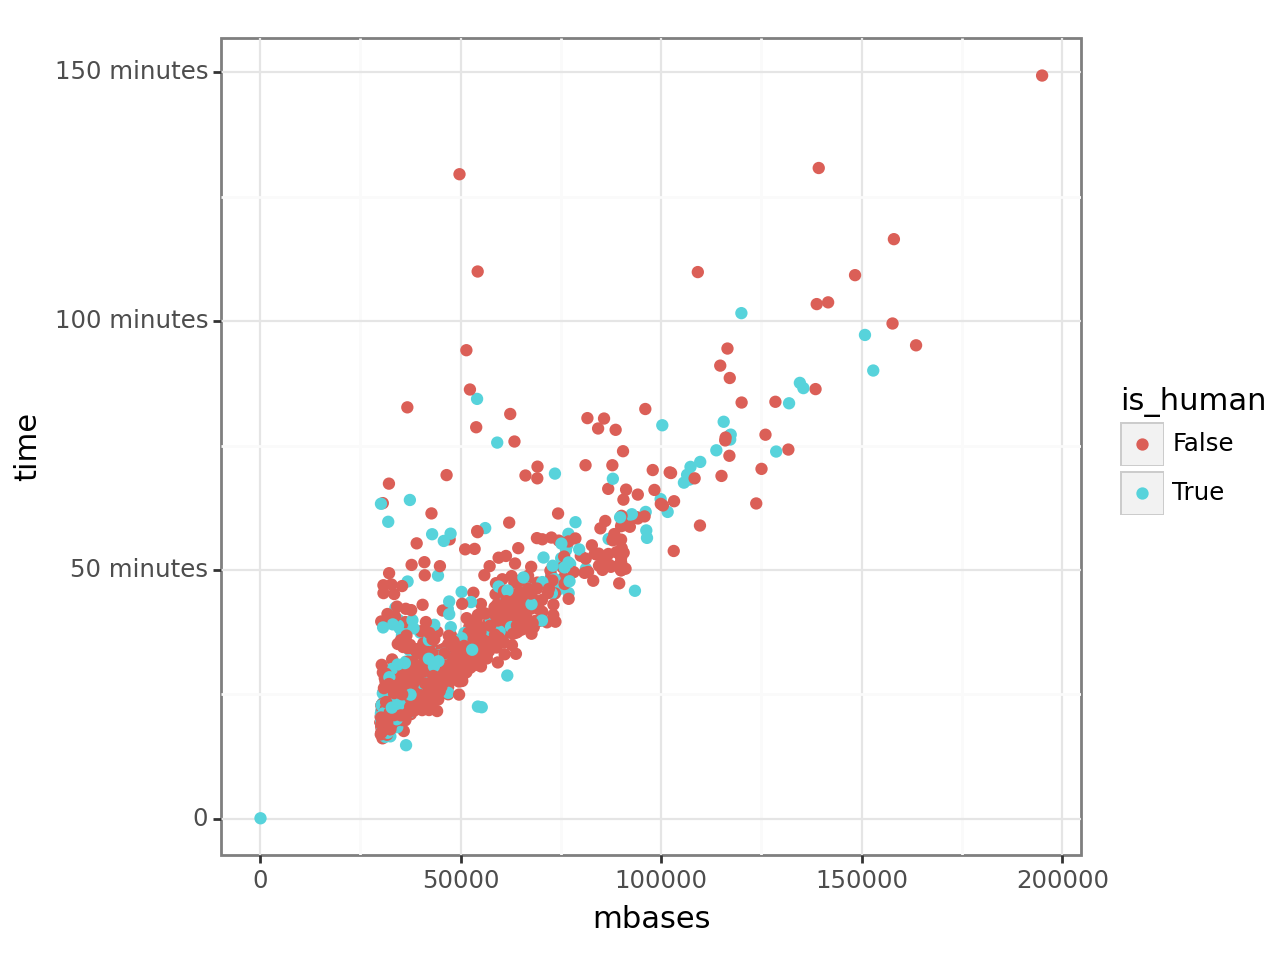

<Figure Size: (640 x 480)>

In [42]:
ggplot(merge)+geom_point(aes(x='mbases', y='time', colour='is_human'))